## Import Libraries

### # Step 1: Import libraries

In [ ]:
import pandas as pd


In [5]:
import numpy as np

In [6]:
import matplotlib.pyplot as plt

In [7]:
import seaborn as sns

In [8]:
from wordcloud import WordCloud, STOPWORDS

plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')


## Load data set

### # Step 2: Load dataset

In [ ]:
df = pd.read_csv('C:/Users/hi/OneDrive/Desktop/python code/Zomato_Analytics-EDA/Indian-Resturants.csv')  # adjust path if needed


In [10]:
df

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211939,3202251,Kali Mirch Cafe And Restaurant,['Casual Dining'],https://www.zomato.com/vadodara/kali-mirch-caf...,"Manu Smriti Complex, Near Navrachna School, GI...",Vadodara,32,Fatehgunj,22.336931,73.192356,...,2,Rs.,"['Dinner', 'Cash', 'Lunch', 'Delivery', 'Indoo...",4.1,Very Good,243,40,0.0,-1,-1
211940,3200996,Raju Omlet,['Quick Bites'],https://www.zomato.com/vadodara/raju-omlet-kar...,"Mahalaxmi Apartment, Opposite B O B, Karoli Ba...",Vadodara,32,Karelibaug,22.322455,73.197203,...,1,Rs.,"['Dinner', 'Cash', 'Takeaway Available', 'Debi...",4.1,Very Good,187,40,0.0,1,-1
211941,18984164,The Grand Thakar,['Casual Dining'],https://www.zomato.com/vadodara/the-grand-thak...,"3rd Floor, Shreem Shalini Mall, Opposite Conqu...",Vadodara,32,Alkapuri,22.310563,73.171163,...,2,Rs.,"['Dinner', 'Cash', 'Debit Card', 'Lunch', 'Tak...",4.0,Very Good,111,38,0.0,-1,-1
211942,3201138,Subway,['Quick Bites'],https://www.zomato.com/vadodara/subway-1-akota...,"G-2, Vedant Platina, Near Cosmos, Akota, Vadodara",Vadodara,32,Akota,22.270027,73.143068,...,2,Rs.,"['Dinner', 'Delivery', 'Credit Card', 'Lunch',...",3.7,Good,128,34,0.0,1,-1


## preview

## # Step 3: Preview

In [ ]:
df.head()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,1,-1


### # Total rows & columns

In [ ]:
df.shape

(211944, 26)

### # Column types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211944 entries, 0 to 211943
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   res_id                211944 non-null  int64  
 1   name                  211944 non-null  object 
 2   establishment         211944 non-null  object 
 3   url                   211944 non-null  object 
 4   address               211810 non-null  object 
 5   city                  211944 non-null  object 
 6   city_id               211944 non-null  int64  
 7   locality              211944 non-null  object 
 8   latitude              211944 non-null  float64
 9   longitude             211944 non-null  float64
 10  zipcode               48757 non-null   object 
 11  country_id            211944 non-null  int64  
 12  locality_verbose      211944 non-null  object 
 13  cuisines              210553 non-null  object 
 14  timings               208070 non-null  object 
 15  

### # - Missing values

In [ ]:
df.isnull().sum()

res_id                       0
name                         0
establishment                0
url                          0
address                    134
city                         0
city_id                      0
locality                     0
latitude                     0
longitude                    0
zipcode                 163187
country_id                   0
locality_verbose             0
cuisines                  1391
timings                   3874
average_cost_for_two         0
price_range                  0
currency                     0
highlights                   0
aggregate_rating             0
rating_text                  0
votes                        0
photo_count                  0
opentable_support           48
delivery                     0
takeaway                     0
dtype: int64

## 4. Data Cleaning

### # Drop duplicates

In [ ]:
df = df.drop_duplicates()


### # Drop irrelevant columns (optional)

In [ ]:
drop_cols = ['url', 'address', 'photo_count', 'opentable_support']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])


### # Handle missing ratings

In [ ]:
df = df[df['aggregate_rating'] > 0]

## 5 Rating Distribution

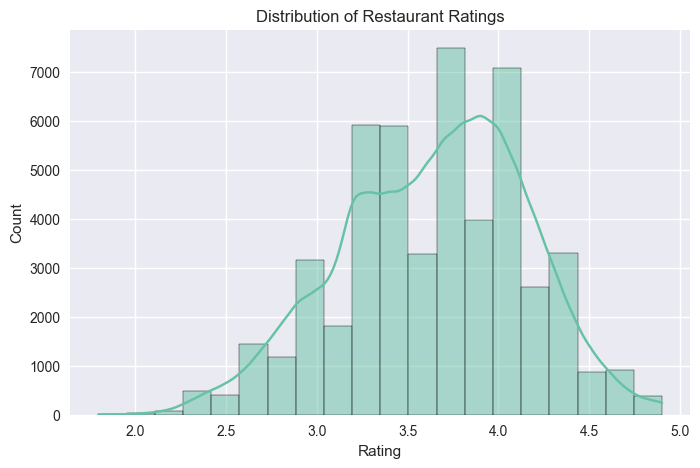

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['aggregate_rating'], bins=20, kde=True)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


## 6. Location Analysis

### # Top cities by count

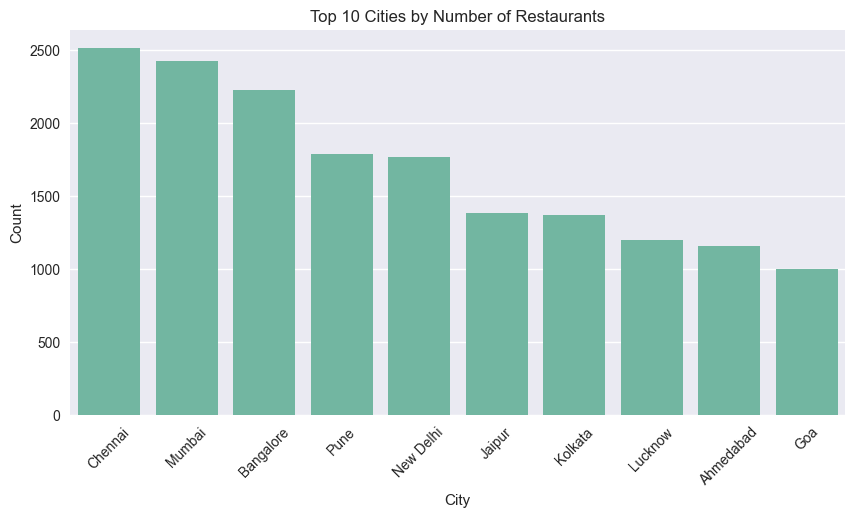

In [ ]:
city_counts = df['city'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=city_counts.index, y=city_counts.values)
plt.xticks(rotation=45)
plt.title('Top 10 Cities by Number of Restaurants')
plt.xlabel('City')
plt.ylabel('Count')
plt.show()



### # Average rating by city

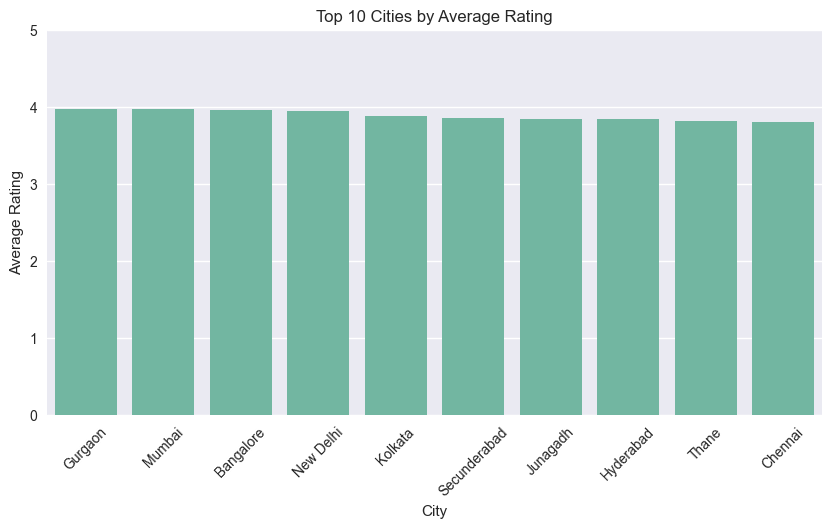

In [ ]:
city_rating = df.groupby('city')['aggregate_rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=city_rating.index, y=city_rating.values)
plt.xticks(rotation=45)
plt.title('Top 10 Cities by Average Rating')
plt.xlabel('City')
plt.ylabel('Average Rating')
plt.ylim(0,5)
plt.show()

## 7. Cuisine Analysis

### # Popular cuisines

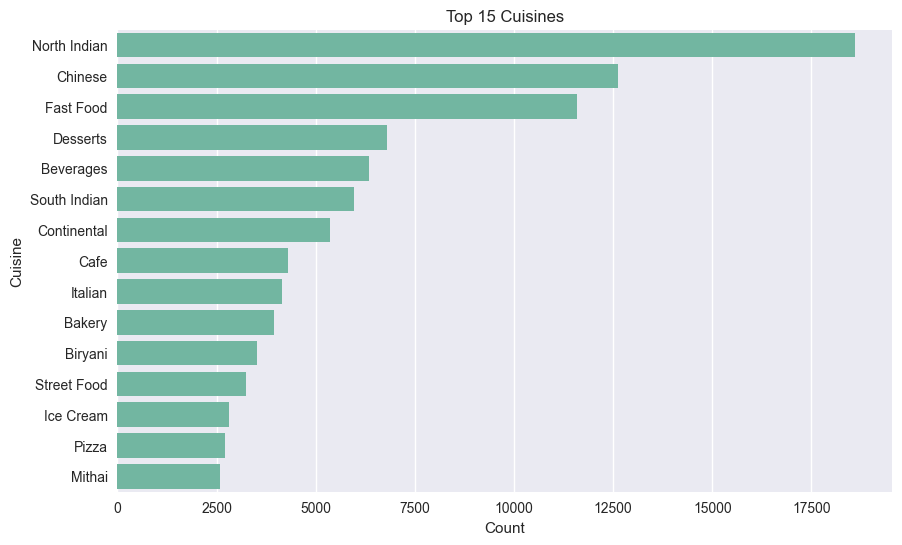

In [ ]:
cuisine_series = df['cuisines'].dropna().str.split(',').explode().str.strip()
top_cuisines = cuisine_series.value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(y=top_cuisines.index, x=top_cuisines.values)
plt.title('Top 15 Cuisines')
plt.xlabel('Count')
plt.ylabel('Cuisine')
plt.show()


## 8. Price Range And Cost

### # Price range distribution

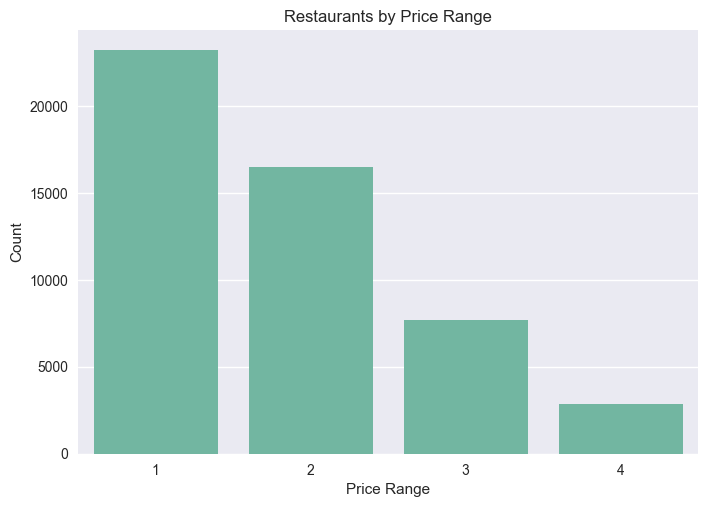

In [ ]:
sns.countplot(data=df, x='price_range')
plt.title('Restaurants by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Count')
plt.show()


### # Average rating by price range

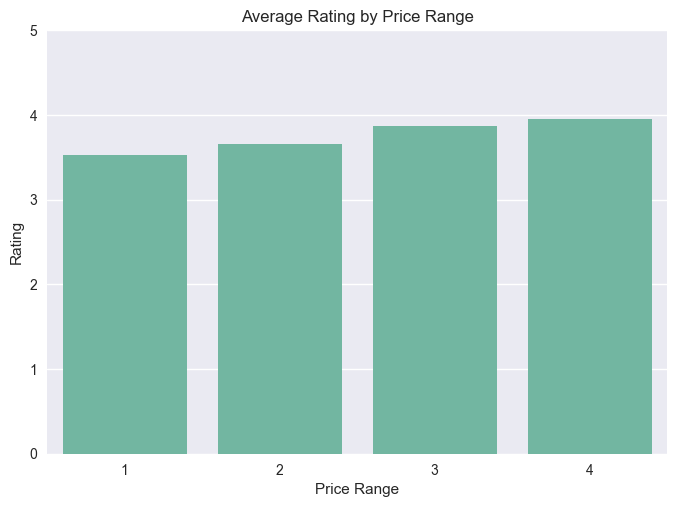

In [ ]:
Xprice_rating = df.groupby('price_range')['aggregate_rating'].mean().reset_index()
sns.barplot(data=price_rating, x='price_range', y='aggregate_rating')
plt.title('Average Rating by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Rating')
plt.ylim(0,5)
plt.show()


## 9. Features Impact(Delivery,Takeaway)

### # Delivery impact

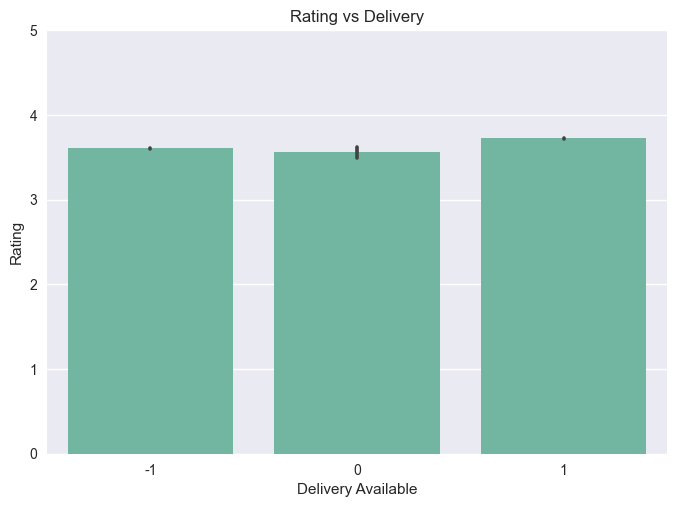

In [ ]:
sns.barplot(x=df['delivery'], y=df['aggregate_rating'])
plt.title('Rating vs Delivery')
plt.xlabel('Delivery Available')
plt.ylabel('Rating')
plt.ylim(0,5)
plt.show()


### # Takeaway impact

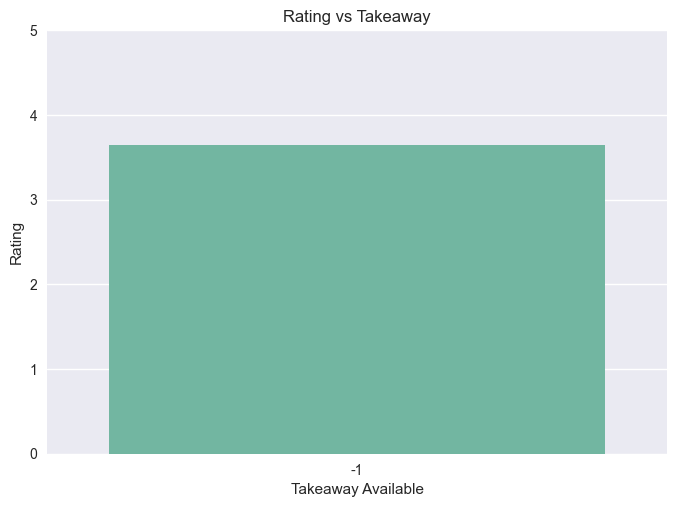

In [ ]:
sns.barplot(x=df['takeaway'], y=df['aggregate_rating'])
plt.title('Rating vs Takeaway')
plt.xlabel('Takeaway Available')
plt.ylabel('Rating')
plt.ylim(0,5)
plt.show()


## 10. Top Restaurant Chains

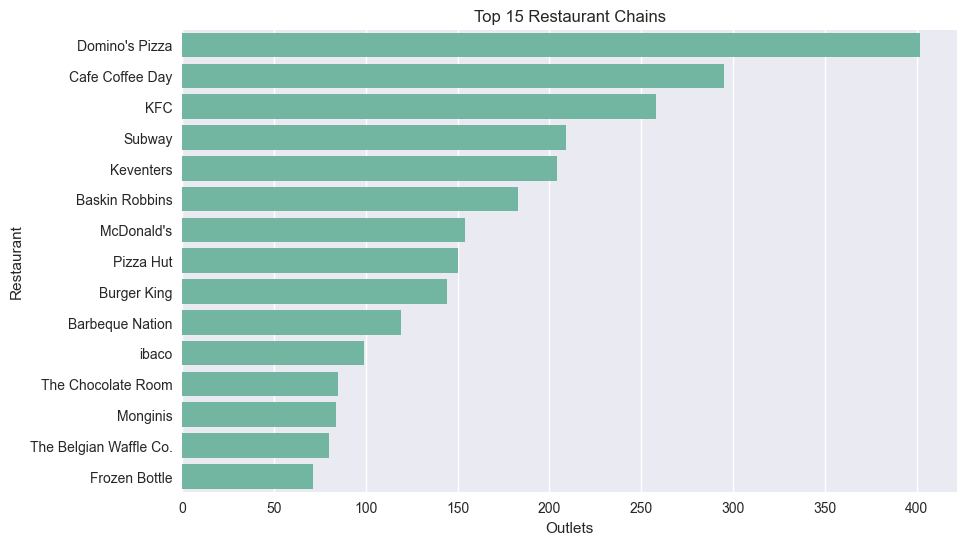

In [26]:
top_chains = df['name'].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(y=top_chains.index, x=top_chains.values)
plt.title('Top 15 Restaurant Chains')
plt.xlabel('Outlets')
plt.ylabel('Restaurant')
plt.show()


## 11. Word Cloud From Highlights

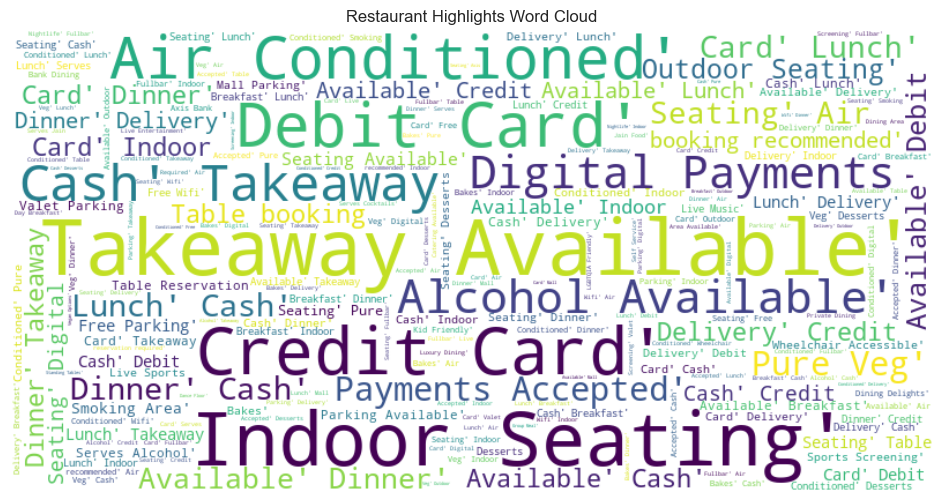

In [27]:
text = " ".join(str(highlight) for highlight in df['highlights'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      stopwords=set(STOPWORDS), max_words=200).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Restaurant Highlights Word Cloud')
plt.show()


## 12. Final Summary 

### Conclusion

- Most restaurants are concentrated in cities like Agra, Delhi, etc.
- North Indian and Fast Food are the most popular cuisines.
- Mid-range price restaurants tend to have better ratings.
- Online delivery and takeaway services show slight positive impact on ratings.
- Top chains like Bhagat Hal and Momo Chini have multiple outlets with decent ratings.

### Recommendations:
- For restaurant owners: Focus on popular cuisines + mid-range pricing + delivery options.
- For Zomato users: Restaurants with takeaway/delivery and 4.0+ ratings offer better experience.
